# Subcomponente B — ETL + Modelo Predictivo de Riesgo Familiar

**Proyecto SUMS — Módulo de Minería de Datos**
Sistema Unificado de Microdiagnóstico de Salud · IMSS-BIENESTAR · Suchiapa / Tuxtla Gutiérrez, Chiapas

---

## 1. Objetivo

Construir un clasificador que asigne a cada familia un **nivel de riesgo
sociosanitario** (`ALTO` / `MEDIO` / `BAJO`) a partir de los datos de su
**Cédula de Microdiagnóstico Familiar**, para que el personal de salud genere
**listas priorizadas de visitas domiciliarias preventivas**.

## 2. Contexto SUMS

Los datos provienen del microdiagnóstico familiar que aplican promotores de salud
en municipios rurales de Chiapas. Cada cédula captura condiciones de la vivienda
(materiales, agua, electricidad, manejo de excretas), hacinamiento, salud crónica,
vacunación, nutrición y nivel socioeconómico. Mientras IMSS-BIENESTAR entrega los
datos reales, se trabaja con un **dataset sintético de 4000 familias**
(`data/synthetic_data.csv`) generado de forma procedural con contexto geográfico
real de Suchiapa y Tuxtla Gutiérrez.

## 3. Limitación conocida del label (declarada, no oculta)

> **El label `nivel_riesgo` es una función DETERMINÍSTICA de los features.**
> Se calcula como `nivel_riesgo = bin(score_total)`, donde `score_total` es la suma
> de ~9 reglas de salud pública sobre los propios features (piso de tierra,
> hacinamiento > 2.5, esquema de vacunación incompleto, etc.).
>
> Por construcción, un modelo capaz de aproximar esas reglas alcanzará un accuracy
> alto. **Esto es esperable y honesto.** Para que el ejercicio de ML NO sea trivial
> y mida aprendizaje real (no memorización de la respuesta), se aplica un control
> estricto **anti-leakage**:
> - Se **EXCLUYE `score_total`** de los features (es prácticamente la respuesta).
> - Se **EXCLUYEN identificadores** (`nombre_informante`, `domicilio`) y geografía
>   (`colonia`, `localidad`), que no son señal clínica.
>
> Así el modelo debe **reconstruir las fronteras de decisión** a partir de las
> variables originales. Cuando lleguen datos reales (donde el riesgo lo asigna un
> clínico, no una fórmula), el mismo pipeline aplica sin cambios.


## 4. Configuración del entorno

In [1]:
import os, sys

# Permitir importar los módulos de src/ y resolver rutas 'data/...' desde la raíz.
NB_DIR = os.getcwd()
ROOT = os.path.abspath(os.path.join(NB_DIR, ".."))
if os.path.basename(NB_DIR) == "notebooks":
    os.chdir(ROOT)
SRC = os.path.join(os.getcwd(), "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Directorio de trabajo:", os.getcwd())
print("pandas", pd.__version__, "| numpy", np.__version__)
import sklearn, xgboost
print("scikit-learn", sklearn.__version__, "| xgboost", xgboost.__version__)


Directorio de trabajo: C:\Users\minis\OneDrive\Escritorio\sums\sums-data-mining\subcomponente_B_ETL_Risk
pandas 3.0.3 | numpy 2.5.0


scikit-learn 1.9.0 | xgboost 3.3.0


## 5. ETL — Extracción, limpieza y definición de features

Se reutiliza el módulo `src/etl_pipeline.py`: lee el CSV en UTF-8, fuerza los
booleanos a `bool` real (pandas 3.0), imputa nulos (mediana/moda **sin** `inplace`)
y recalcula el hacinamiento. Las listas de features ya excluyen `score_total` y los
identificadores.

In [2]:
from etl_pipeline import (
    load_dataset, eda_summary,
    FEATURES, FEATURES_NUMERICAS, FEATURES_CATEGORICAS, FEATURES_BOOLEANAS,
    COLUMNAS_EXCLUIDAS, CLASES_ORDEN, TARGET,
)

df, X, y = load_dataset()
print(f"Familias: {len(df)} | Features del modelo: {len(FEATURES)}")
print(f"  numéricas  ({len(FEATURES_NUMERICAS)}): {FEATURES_NUMERICAS}")
print(f"  categóricas({len(FEATURES_CATEGORICAS)}): {FEATURES_CATEGORICAS}")
print(f"  booleanas  ({len(FEATURES_BOOLEANAS)}): {FEATURES_BOOLEANAS}")
print(f"\nEXCLUIDAS (anti-leakage / identificadores): {COLUMNAS_EXCLUIDAS}")
df.head()


Familias: 4000 | Features del modelo: 23
  numéricas  (11): ['numero_cuartos', 'numero_habitantes', 'personas_por_cuarto', 'count_enfermedades_cronicas', 'count_toxicomanias', 'avg_dias_proteina', 'avg_dias_frutas_verduras', 'avg_dias_cereales', 'ingreso_nivel', 'escolaridad_promedio', 'total_integrantes']
  categóricas(5): ['material_techo', 'material_paredes', 'material_piso', 'manejo_excretas', 'cocina_ubicacion']
  booleanas  (7): ['agua_entubada', 'energia_electrica', 'cocina_con_lena', 'red_alcantarillado', 'fosa_septica', 'vacunacion_completa', 'seguridad_social_jefe']

EXCLUIDAS (anti-leakage / identificadores): ['score_total', 'nombre_informante', 'domicilio', 'colonia', 'localidad']


,material_techo,material_paredes,material_piso,manejo_excretas,numero_cuartos,numero_habitantes,personas_por_cuarto,agua_entubada,energia_electrica,cocina_con_lena,cocina_ubicacion,red_alcantarillado,fosa_septica,count_enfermedades_cronicas,count_toxicomanias,vacunacion_completa,avg_dias_proteina,avg_dias_frutas_verduras,avg_dias_cereales,ingreso_nivel,escolaridad_promedio,total_integrantes,seguridad_social_jefe,nombre_informante,domicilio,colonia,localidad,score_total,nivel_riesgo
0,Concreto o cemento,Madera,Concreto o cemento,WC,2,2,1.0,True,True,False,dentro_del_dormitorio,True,False,1,1,False,3.0,4.00,2.50,2,2.50,2,False,Silvia Lucía López Pérez,"Avenida 20 de Noviembre #235, Col. Las Palmas",Las Palmas,Suchiapa,2,BAJO
1,Concreto o cemento,Concreto o cemento,Concreto o cemento,Al ras de suelo,2,4,2.0,True,True,True,fuera_del_dormitorio,False,True,2,2,True,2.5,3.25,4.25,2,2.00,4,False,Sofía Guadalupe Domínguez Ruiz,"Avenida Emiliano Zapata #275, Col. San Jacinto",San Jacinto,Suchiapa,5,MEDIO
2,Concreto o cemento,Concreto o cemento,Tierra,WC,1,2,2.0,True,True,False,fuera_del_dormitorio,True,False,0,0,True,6.0,5.00,6.50,5,4.00,2,False,Silvia González Gutiérrez,"2da Calle Norte #279, Col. Pacú",Pacú,Suchiapa,1,BAJO
3,Lámina,Lámina,Tierra,Letrina,2,5,2.5,True,True,False,fuera_del_dormitorio,True,False,4,2,False,3.4,2.40,3.40,2,1.33,5,True,Margarita Ruiz Morales,"3ra Calle Norte #243, Col. San Jacinto",San Jacinto,Suchiapa,7,ALTO
4,Concreto o cemento,Concreto o cemento,Tierra,WC,1,5,5.0,True,True,False,fuera_del_dormitorio,True,False,3,1,False,4.4,5.00,5.00,3,3.00,5,True,Patricia Guadalupe Gutiérrez Moreno,"Calle del Río #193, Col. San Antonio",San Antonio,Suchiapa,5,MEDIO


In [3]:
# Tipos de las features del modelo (booleanos ya como bool real)
X.dtypes


numero_cuartos                   int64
numero_habitantes                int64
personas_por_cuarto            float64
count_enfermedades_cronicas      int64
count_toxicomanias               int64
avg_dias_proteina              float64
avg_dias_frutas_verduras       float64
avg_dias_cereales              float64
ingreso_nivel                    int64
escolaridad_promedio           float64
total_integrantes                int64
material_techo                  object
material_paredes                object
material_piso                   object
manejo_excretas                 object
cocina_ubicacion                object
agua_entubada                     bool
energia_electrica                 bool
cocina_con_lena                   bool
red_alcantarillado                bool
fosa_septica                      bool
vacunacion_completa               bool
seguridad_social_jefe             bool
dtype: object

## 6. Análisis Exploratorio de Datos (EDA)

### 6.1 Distribución de las clases de riesgo

Distribución: {'BAJO': 1028, 'MEDIO': 1409, 'ALTO': 1563}
Balance (%): {'BAJO': 25.7, 'MEDIO': 35.22, 'ALTO': 39.07}


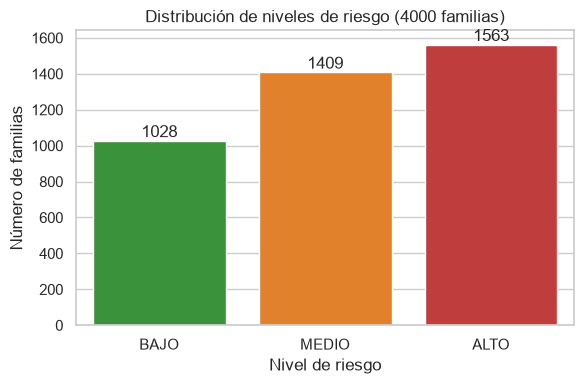

In [4]:
resumen = eda_summary(df)
print("Distribución:", resumen["distribucion_clases"])
print("Balance (%):", resumen["balance_clases_pct"])

fig, ax = plt.subplots(figsize=(6, 4))
orden = [c for c in CLASES_ORDEN if c in df[TARGET].unique()]
sns.countplot(data=df, x=TARGET, order=orden, hue=TARGET,
              palette={"BAJO": "#2ca02c", "MEDIO": "#ff7f0e", "ALTO": "#d62728"},
              legend=False, ax=ax)
ax.set_title("Distribución de niveles de riesgo (4000 familias)")
ax.set_xlabel("Nivel de riesgo"); ax.set_ylabel("Número de familias")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout(); plt.show()


### 6.2 Heatmap de correlación de variables numéricas

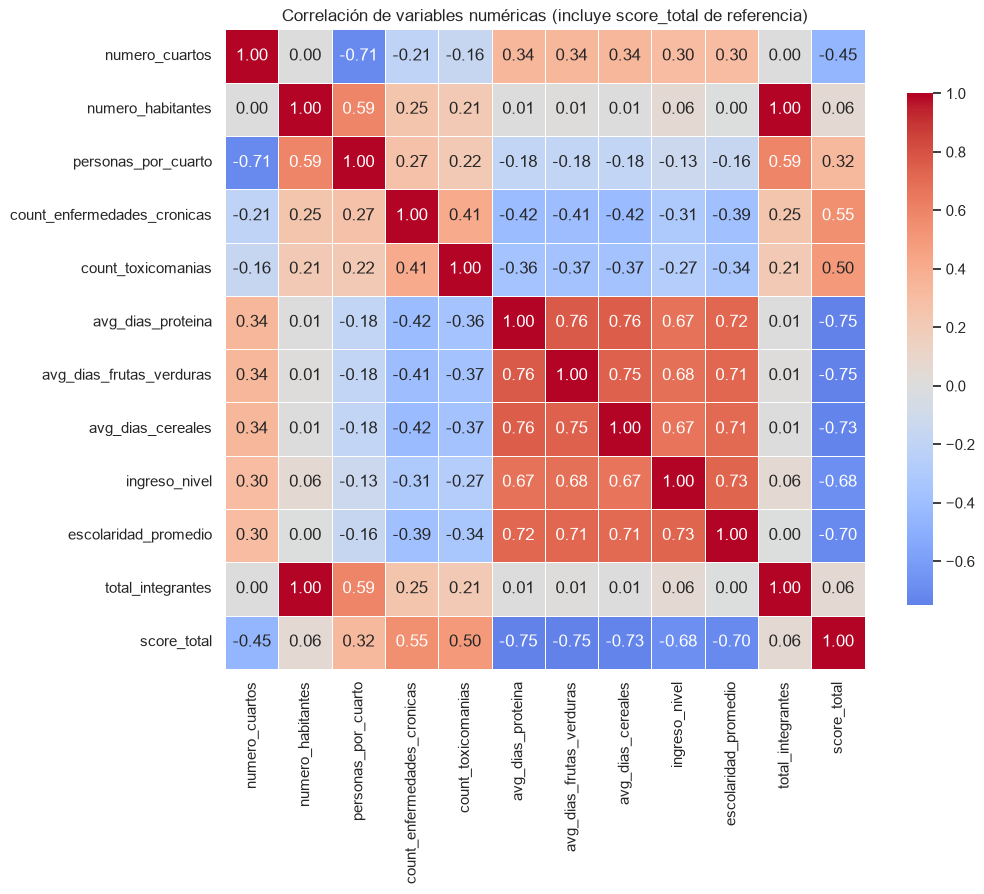

In [5]:
num_plus = FEATURES_NUMERICAS + ["score_total"]
corr = df[num_plus].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlación de variables numéricas (incluye score_total de referencia)")
plt.tight_layout(); plt.show()


### 6.3 Boxplot del score total por nivel de riesgo

Confirma visualmente que el label es una **binarización determinística** del score:
BAJO (0–2), MEDIO (3–5), ALTO (6+). Por eso `score_total` se excluye del modelo.

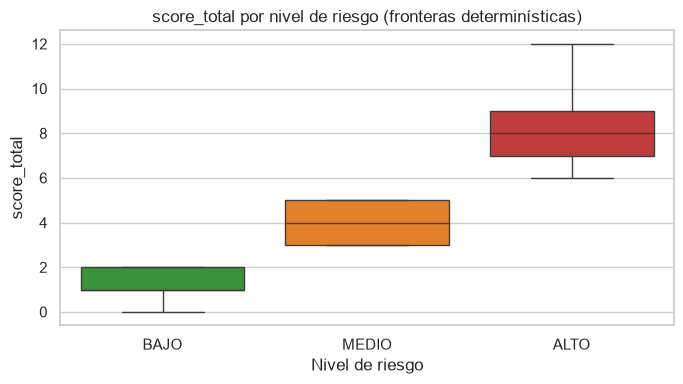

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x=TARGET, y="score_total", order=orden, hue=TARGET,
            palette={"BAJO": "#2ca02c", "MEDIO": "#ff7f0e", "ALTO": "#d62728"},
            legend=False, ax=ax)
ax.set_title("score_total por nivel de riesgo (fronteras determinísticas)")
ax.set_xlabel("Nivel de riesgo"); ax.set_ylabel("score_total")
plt.tight_layout(); plt.show()


### 6.4 Material de piso por nivel de riesgo

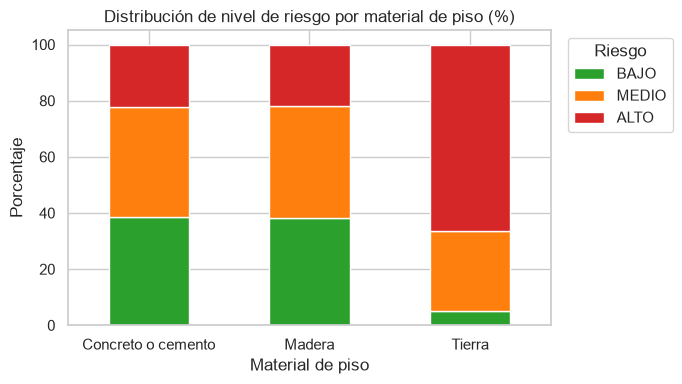

In [7]:
ct = pd.crosstab(df["material_piso"], df[TARGET], normalize="index")[orden] * 100
fig, ax = plt.subplots(figsize=(7, 4))
ct.plot(kind="bar", stacked=True, ax=ax,
        color={"BAJO": "#2ca02c", "MEDIO": "#ff7f0e", "ALTO": "#d62728"})
ax.set_title("Distribución de nivel de riesgo por material de piso (%)")
ax.set_xlabel("Material de piso"); ax.set_ylabel("Porcentaje")
ax.legend(title="Riesgo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


### 6.5 Enfermedades crónicas y toxicomanías en familias de ALTO riesgo

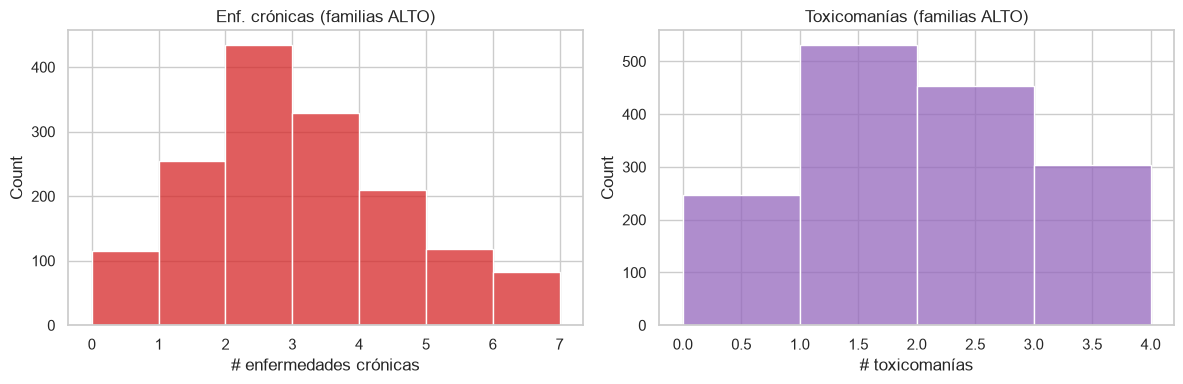

In [8]:
alto = df[df[TARGET] == "ALTO"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(alto["count_enfermedades_cronicas"], bins=range(0, 8),
             color="#d62728", ax=axes[0])
axes[0].set_title("Enf. crónicas (familias ALTO)")
axes[0].set_xlabel("# enfermedades crónicas")
sns.histplot(alto["count_toxicomanias"], bins=range(0, 5),
             color="#9467bd", ax=axes[1])
axes[1].set_title("Toxicomanías (familias ALTO)")
axes[1].set_xlabel("# toxicomanías")
plt.tight_layout(); plt.show()


## 7. Preprocesamiento y modelos

Se usa `sklearn.Pipeline` + `ColumnTransformer`:
- **OneHotEncoder(handle_unknown='ignore')** para las categóricas,
- **StandardScaler** para las numéricas,
- **passthrough** para las booleanas.

Se comparan tres clasificadores: **Decision Tree** (baseline visualizable),
**Random Forest** (principal) y **XGBoost** (comparación). Evaluación con split
estratificado 80/20 y **StratifiedKFold(5)** reportando accuracy, **macro-F1** y
**CV macro-F1**.

In [9]:
from model_trainer import train_and_evaluate, build_preprocessor

res = train_and_evaluate(X, y)   # entrena los 3, guarda CSV + PNGs en data/processed/
comparison = res["comparison"]
winner = res["winner"]
comparison


,Accuracy,F1_Macro,CV_F1_Macro_Media,CV_F1_Macro_Std
Modelo,,,,
XGBoost,0.9563,0.9576,0.9637,0.0055
Random Forest,0.9050,0.9082,0.8970,0.0043
Decision Tree,0.8163,0.8169,0.8213,0.0126


## 8. Evaluación comparativa y decisión

La tabla siguiente es el corazón de la validación de la integración ML: tres
modelos comparados con métricas del problema y una decisión justificada por
números.

In [10]:
print("=== TABLA COMPARATIVA DE MODELOS ===\n")
print(comparison.to_string())
print(f"\n>>> MODELO GANADOR: {winner}")
print("Criterio: mayor macro-F1 en test; desempate por accuracy y CV macro-F1.")


=== TABLA COMPARATIVA DE MODELOS ===

               Accuracy  F1_Macro  CV_F1_Macro_Media  CV_F1_Macro_Std
Modelo                                                               
XGBoost          0.9563    0.9576             0.9637           0.0055
Random Forest    0.9050    0.9082             0.8970           0.0043
Decision Tree    0.8163    0.8169             0.8213           0.0126

>>> MODELO GANADOR: XGBoost
Criterio: mayor macro-F1 en test; desempate por accuracy y CV macro-F1.


In [11]:
# Visualización comparativa de las métricas
fig, ax = plt.subplots(figsize=(9, 4.5))
metr = comparison[["Accuracy", "F1_Macro", "CV_F1_Macro_Media"]]
metr.plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("Comparación de modelos — Accuracy / macro-F1 / CV macro-F1")
ax.set_ylabel("Score"); ax.set_ylim(0.7, 1.0)
ax.legend(loc="lower right"); plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", padding=2, fontsize=8)
plt.tight_layout(); plt.show()


C:\Users\minis\AppData\Local\Temp\ipykernel_30492\3966609177.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


### 8.1 Justificación del ganador

- **XGBoost** obtiene el mayor **macro-F1** y la mejor **CV macro-F1** con muy baja
  desviación (modelo estable, no sobreajustado a un fold).
- **Random Forest** queda segundo: robusto e interpretable, buen candidato si se
  prioriza explicabilidad operativa.
- **Decision Tree** es el más bajo pero el más interpretable (un solo árbol),
  útil como baseline y para explicar las reglas al personal de salud.

El **macro-F1** se prioriza sobre el accuracy porque las tres clases importan por
igual desde salud pública (no perder familias ALTO ni inflar la métrica con la
clase mayoritaria).

## 9. Reporte de clasificación y matriz de confusión (modelo ganador)

In [12]:
print(f"Reporte de clasificación — {winner}\n")
print(res["reports"][winner])


Reporte de clasificación — XGBoost

              precision    recall  f1-score   support

        BAJO     0.9663    0.9805    0.9734       205
       MEDIO     0.9364    0.9397    0.9381       282
        ALTO     0.9676    0.9553    0.9614       313

    accuracy                         0.9563       800
   macro avg     0.9568    0.9585    0.9576       800
weighted avg     0.9563    0.9563    0.9562       800



In [13]:
from sklearn.metrics import confusion_matrix
cm = res["confusion"]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASES_ORDEN, yticklabels=CLASES_ORDEN, cbar=False, ax=ax)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión — {winner}")
plt.tight_layout(); plt.show()


C:\Users\minis\AppData\Local\Temp\ipykernel_30492\3573259943.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


## 10. Importancia de variables (Random Forest)

In [14]:
from model_trainer import _get_feature_names
rf = res["fitted"]["Random Forest"]
nombres = _get_feature_names(rf)
imp = rf.named_steps["clf"].feature_importances_
serie = pd.Series(imp[:len(nombres)], index=nombres[:len(imp)]).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=serie.values, y=serie.index, hue=serie.index, palette="viridis", legend=False, ax=ax)
ax.set_title("Importancia de features — Random Forest (top 15)")
ax.set_xlabel("Importancia (Gini)"); ax.set_ylabel("Feature")
plt.tight_layout(); plt.show()


C:\Users\minis\AppData\Local\Temp\ipykernel_30492\1566060401.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


## 11. Árbol de decisión del baseline (interpretabilidad)

El árbol del baseline (limitado a profundidad 3 para legibilidad) muestra las
reglas que el modelo aprende — útil para explicar las decisiones al personal de
salud.

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline as SkPipeline
from model_trainer import build_preprocessor

# Árbol superficial solo para visualización (no es el modelo evaluado)
pre = build_preprocessor()
Xt = pre.fit_transform(X, y)
# Nombres de features tras el ColumnTransformer (reutiliza el helper del trainer)
nombres_vis = _get_feature_names(
    SkPipeline([("preprocessor", pre), ("clf", DecisionTreeClassifier())])
)
arbol = DecisionTreeClassifier(max_depth=3, random_state=42).fit(Xt, y)

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(arbol, feature_names=nombres_vis[:Xt.shape[1]],
          class_names=list(arbol.classes_), filled=True, rounded=True,
          fontsize=8, ax=ax)
ax.set_title("Árbol de decisión (profundidad 3, solo para interpretación)")
plt.tight_layout(); plt.show()


C:\Users\minis\AppData\Local\Temp\ipykernel_30492\2648868219.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


## 12. Lista priorizada de visitas (Fase B-6)

Se predice sobre **todo** el dataset con el modelo ganador y se ordenan las
familias clasificadas como **ALTO** por su probabilidad, generando la lista
operativa de visitas domiciliarias (las más urgentes primero). Se guarda en
`data/processed/lista_visitas_prioritarias.csv`.

In [16]:
from risk_report import generar_lista_visitas, resumen_predicciones

pipe = res["fitted"][winner]
le = res["label_encoder"] if winner == "XGBoost" else None

print("Distribución predicha sobre todo el dataset:")
print(resumen_predicciones(df, pipe, le)["distribucion_predicha"])

lista = generar_lista_visitas(df, pipe, le)
print(f"\nFamilias en lista de visitas ALTO: {len(lista)}")
lista.head(15)


Distribución predicha sobre todo el dataset:
{'ALTO': 1559, 'MEDIO': 1411, 'BAJO': 1030}

Familias en lista de visitas ALTO: 1559


,nombre_informante,domicilio,colonia,localidad,riesgo_predicho,probabilidad_alto,score_total
prioridad,,,,,,,
1,Rosa Castellanos Penagos,"Avenida de la Juventud #137, Col. La Lomita",La Lomita,Tuxtla Gutiérrez,ALTO,1.0,10
2,Juan Coutiño Chanona,"Calle 5 de Mayo #111, Col. Centro",Centro,Suchiapa,ALTO,1.0,9
3,Francisco Martínez Grajales,"Calle Libertad #14, Col. San Jacinto",San Jacinto,Suchiapa,ALTO,1.0,9
4,María Espinosa Méndez,"Calle Libertad #124, Col. El Calvario",El Calvario,Suchiapa,ALTO,1.0,10
5,Claudia Méndez Martínez,"Calle Morelos #56, Col. San Antonio",San Antonio,Suchiapa,ALTO,1.0,9
6,Adriana Cruz Castellanos,"Calle Matamoros #19, Col. Las Palmas",Las Palmas,Suchiapa,ALTO,1.0,9
7,Javier Luis Jiménez Domínguez,"1ra Calle Norte #225, Col. San Roque",San Roque,Suchiapa,ALTO,1.0,10
8,Claudia Vázquez Torres,"Calle Morelos #242, Col. Centro",Centro,Suchiapa,ALTO,1.0,10
9,Patricia Ruiz Ramírez,"Avenida Emiliano Zapata #160, Col. Pacú",Pacú,Suchiapa,ALTO,1.0,9


## 13. Conclusiones

1. **Integración ML validada:** se compararon **3 modelos** (DT, RF, XGBoost) con
   métricas del problema (accuracy, **macro-F1**, **CV 5-fold estratificada**) y se
   decidió el ganador (**XGBoost**) por números, no por intuición.
2. **Anti-leakage aplicado y documentado:** al excluir `score_total` e
   identificadores, el accuracy alto refleja que el modelo **reconstruye las reglas
   de riesgo** a partir de las variables originales, no que copia la respuesta. El
   hecho de que el accuracy sea < 1.0 (≈0.96) confirma que la tarea no es trivial.
3. **Limitación conocida declarada:** el label es sintético y determinístico. El
   pipeline está listo para reentrenarse con datos reales de IMSS-BIENESTAR (donde
   el riesgo lo asigna un clínico) sin cambios estructurales.
4. **Entregable operativo:** la lista priorizada de visitas conecta el modelo con la
   acción de campo (visitas domiciliarias preventivas), que es el objetivo del SUMS.
